# 01 — Data exploration with yfinance

We wil pull *daily* OHLCV (yfinance is rate-limited and only gives
1-minute bars for the last 7 days). Daily is enough for Phase 1
milestones; the agent will be re-trained on minute data later.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

from backend.config.constants import TARGET_TICKERS, TICKER_TO_SECTOR

UNIVERSE = sorted(TARGET_TICKERS)
START = date(2018, 1, 1)
END = date(2024, 12, 31)
print(f"Universe: {len(UNIVERSE)} tickers")

Universe: 32 tickers


## Bulk download

In [2]:
raw = yf.download(
    UNIVERSE,
    start=START,
    end=END,
    interval="1d",
    auto_adjust=False,
    progress=False,
    threads=True,
)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns.levels[0]))

Shape: (1760, 192)
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


## Sanity: rows per ticker

In [3]:
close = raw["Close"]
counts = close.notna().sum().sort_values()
print(counts.head(10))
print(counts.tail(10))
# We expect ~1750 traiding days for the full window. Anything < 1500
# probably means a delisting or a young ETF.

Ticker
AAPL    1760
ABBV    1760
ADBE    1760
AMD     1760
AMZN    1760
AVGO    1760
BAC     1760
COP     1760
COST    1760
CRM     1760
dtype: int64
Ticker
NVDA    1760
ORCL    1760
PFE     1760
QQQ     1760
SPY     1760
TSLA    1760
UNH     1760
V       1760
WMT     1760
XOM     1760
dtype: int64


## Cumulative returns

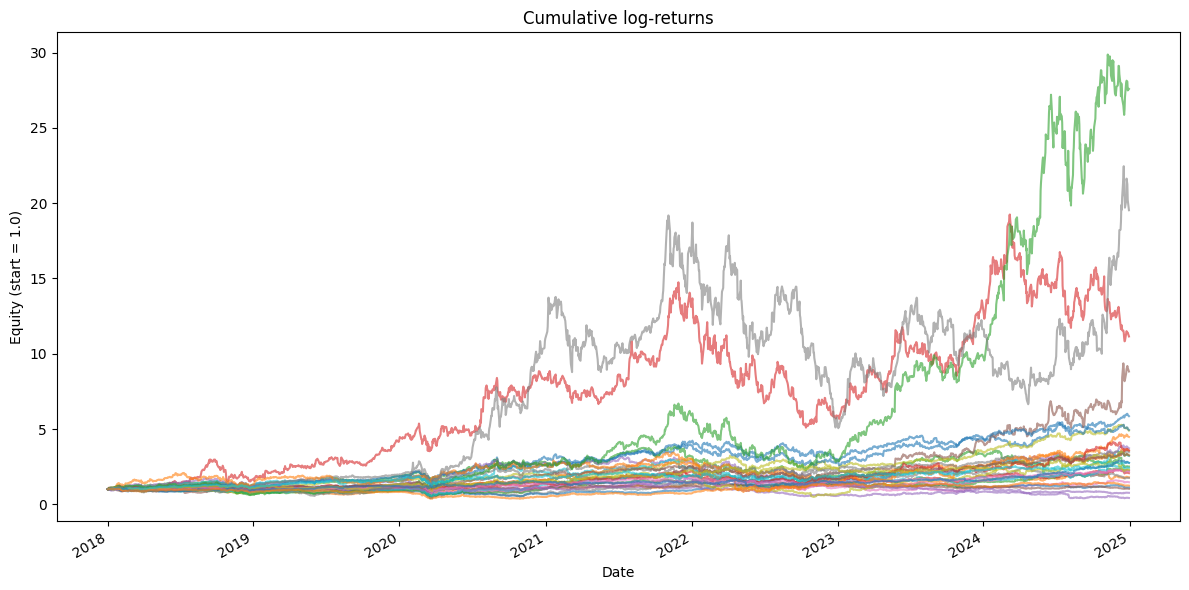

In [4]:
returns = np.log(close / close.shift(1))
cum = returns.cumsum().fillna(0).apply(np.exp)
fig, ax = plt.subplots(figsize=(12, 6))
cum.plot(ax=ax, alpha=0.6, legend=False)
ax.set_title("Cumulative log-returns")
ax.set_ylabel("Equity (start = 1.0)")
plt.tight_layout()
plt.savefig("../reports/01_cumulative_returns.png", dpi=120)

## Sector-grounded correlation matrix

A first sanity check on the GATv2 input: tickers in the same sector
should be more correlated than tickers in different sectors.

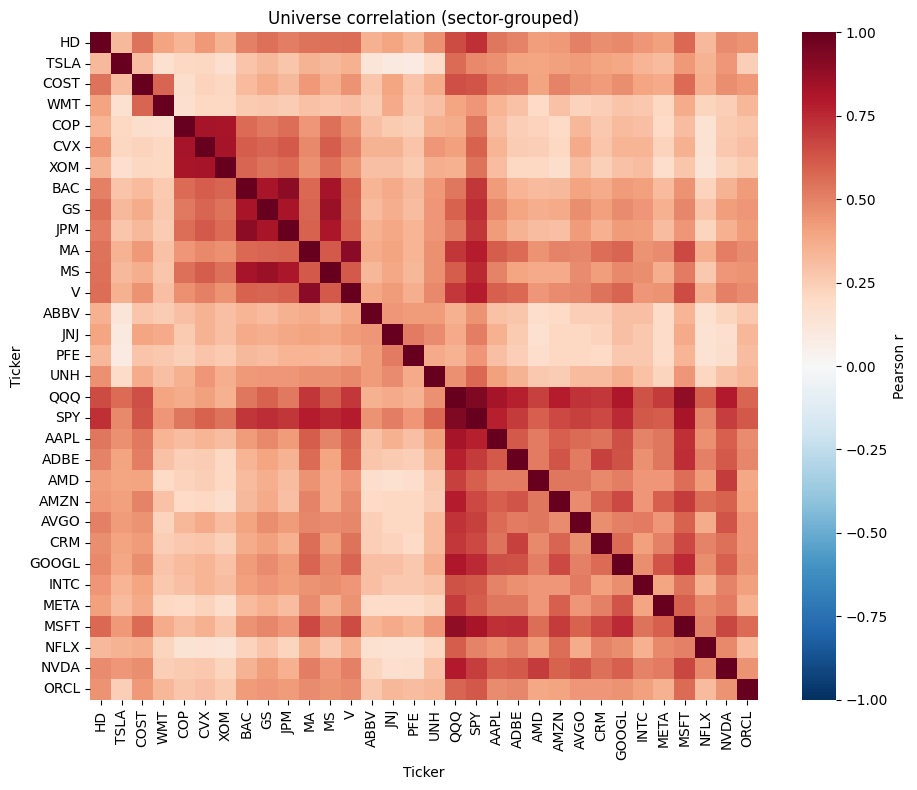

In [5]:
corr = returns.corr()
order = sorted(UNIVERSE, key=lambda t: TICKER_TO_SECTOR.get(t, "zz"))
corr = corr.reindex(index=order, columns=order)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Universe correlation (sector-grouped)")
plt.tight_layout()
plt.savefig("../reports/01_correlation_matrix.png", dpi=120)

## Intra-sector vs inter-sector correlation

In [6]:
def sector(t):
    return TICKER_TO_SECTOR.get(t, "?")


intra, inter = [], []
for i, a in enumerate(UNIVERSE):
    for b in UNIVERSE[i + 1 :]:
        if pd.isna(corr.loc[a, b]):
            continue
        (intra if sector(a) == sector(b) else inter).append(corr.loc[a, b])
print(f"Intra-sector mean r: {np.mean(intra):.3f} (n={len(intra)})")
print(f"Inter-sector mean r: {np.mean(inter):.3f} (n={len(inter)})")
# Healthy data should have intra > inter by ~0.05 to 0.15.

Intra-sector mean r: 0.560 (n=105)
Inter-sector mean r: 0.398 (n=391)
